# Lab 2: Hardware–Software Model Co-Design

### Introduction

In **Lab 1**, you saw that compressing transformer weights down to **2 bits** reduced model size by ×16 with only a modest accuracy drop. But compression alone is a *software-centric* solution; actual deployment only succeeds when the model cooperates with the underlying silicon.

In this lab, you’ll adopt a **hardware–software co-design** perspective, treating quantization as the critical interface between the network and its deployment hardware. Quantization affects both **model accuracy** and **execution efficiency**, making it the ideal lever for co-design.

Specifically, you will:

- **Wrap every `nn.Linear` in a quantized integer-only `QLinear` module**  
- **Post-quantize both weights and activations layerwise**, selecting precision from **8 → 2 bits** for each individual layer 
- **Measure performance of each quantization configuration** using **Cross Entropy** and **memory consumption**  
- **Perform automated layerwise bit-width search** to optimize a hardware-aware objective function

> **Why co-design matters:**  
> A model that looks efficient in software may still bottleneck on real hardware due to memory access patterns, compute throughput, or unsupported bit-widths. Hardware–software co-design ensures the model structure aligns with hardware constraints, enabling deployment that is both **accurate** and **efficient** on edge devices.

---

### Lab Objectives

1. **Implement `QLinear`**, a simulated integer GEMM layer with scale-offset dequantization, compatible with PyTorch CPU kernels  
2. **Post-quantize a pretrained model checkpoint** using per-layer {8, 4, 2}-bit precision, and export metadata for downstream evaluation  
3. **Profile** model size and **Validation Cross Entropy**  
4. **Run a non-linear optimization algorithm** to identify a per-layer quantization configuration that minimizes a joint objective (accuracy vs. efficiency)

---

By the end, you'll produce a deployment-ready language model with a **per-layer optimal quantization configuration**, striking the best trade-off between hardware efficiency and model fidelity.



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
from typing import Dict, Any, Tuple

import pytorch_lightning as pl
from hyperopt import fmin, tpe, rand, hp, Trials, space_eval, STATUS_OK

from src.lab1.shakespeare_trainer import ShakespeareModule

/home/oliver/github/Advanced-AI-pt-2/venv/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Building `QLinear`

The first step is to implement a quantized linear layer that supports configurable bit-widths. This will allow us to experiment with different per-layer quantization strategies and conduct a hardware–software co-design process to identify an optimal configuration for deployment.

We’ll define a `QLinear` layer that performs **symmetric uniform quantization**, mapping floating-point tensors to signed integers in the range  
$ - (2^{b-1} - 1), \dots, + (2^{b-1} - 1) $, using a single scale factor **s**.

### Forward Pass Overview:

1. **Quantize** input activations to signed integers.  
2. Perform **GEMM** (general matrix multiplication) using pre-quantized weights.  
3. **Dequantize** the accumulator by multiplying it with the product of the input and weight scale factors.  
4. Add the (floating-point) bias term if used.

>  This implementation prioritizes clarity over performance.



In [2]:
class QLinear(nn.Module):
    """
    A fully-connected layer with symmetric uniform quantization for weights and activations.
    """
    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        weight_bitwidth: int = 8,
        act_bitwidth: int = 8,
    ) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_bitwidth = weight_bitwidth
        self.act_bitwidth = act_bitwidth

        # Buffers to hold quantized weight and quantization scale
        self.register_buffer(
            "qweight",
            torch.zeros(out_features, in_features, dtype=torch.float32),
        )
        self.register_buffer("weight_scale", torch.ones(1))

        # Optional bias
        if bias:
            self.register_buffer("bias", torch.zeros(out_features, dtype=torch.float32))
        else:
            self.bias = None

    @staticmethod
    def _quantize_tensor(
        x: torch.Tensor, bitwidth: int
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Quantize a tensor to signed integers in range [-2^(b-1), 2^(b-1)-1].
        Returns (quantized_tensor, scale).
        """
        qmax = 2 ** (bitwidth - 1) - 1
        rmax = x.abs().max() 
        scale = rmax / qmax if rmax > 0 else torch.tensor(1.0, device=x.device)
        q = torch.clamp(torch.round(x / scale), -qmax, qmax)
        return q, scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Quantize activations
        qx, act_scale = self._quantize_tensor(x, self.act_bitwidth)

        # 2. Integer GEMM
        qx = qx.to(self.qweight.dtype)
        acc = qx.matmul(self.qweight.t())

        # 3. Dequantize
        y = acc * act_scale * self.weight_scale

        # 4. Add bias if present
        if self.bias is not None:
            y = y + self.bias

        return y

    def __repr__(self) -> str:
        # Name of the layer
        return (
            f"{self.__class__.__name__}("
            f"in={self.in_features}, out={self.out_features}, "
            f"w_bits={self.weight_bitwidth}, a_bits={self.act_bitwidth})"
        )

### Quick Sanity Check

Run the cell below to quantize a random matrix at 2, 4, and 8-bit precision,  
and print the reconstruction error.  
> As bit-width increases, the reconstruction error should decrease. Let's run the cell below just to check that. 


In [3]:
# %% 
torch.manual_seed(0)
sample = torch.randn(1000)
for b in (2, 4, 8):
    q, s = QLinear._quantize_tensor(sample, b)
    err = (sample - q * s).abs().mean().item()
    print(f"{b}-bit | mean-abs-error: {err:.6f}")


2-bit | mean-abs-error: 0.761839
4-bit | mean-abs-error: 0.144003
8-bit | mean-abs-error: 0.008115


## 2. Swapping Layers In-Place

To enable **per-layer mixed-precision quantization**, where each layer can be quantized with an arbitrary bit-width, we define a function that traverses the model and replaces each `nn.Linear` layer with a quantized equivalent.

The key mechanism relies on a dictionary called **`qconfig`** which maps the fully qualified names of `nn.Linear` modules to their desired bit-widths. This configuration is then used to locate and swap the corresponding layers in-place with quantized versions (`QLinear`) that store the quantized weights.

The functions below implement this mechanism:
- `quantize_linear`: replaces a single `nn.Linear` with a quantized version given a particular weight bit-width.
- `quantize_model`: applies `quantize_linear` to each layer in the model, quantizing with the per-layer precision specified in `qconfig`.
- `default_qconfig`: generates a default `qconfig` dictionary in which every layer has 8-bit precision.

The `qconfig` dictionary looks like this:

```text
{
  "model.transformer_blocks.0.attn.q_proj": 4,
  "model.transformer_blocks.0.attn.k_proj": 2,
  ...
}

In [4]:
def quantize_linear(layer: nn.Linear, weight_bitwidth=8, act_bitwidth=8):
    qlayer = QLinear(layer.in_features, layer.out_features,
                     bias=layer.bias is not None,
                     weight_bitwidth=weight_bitwidth,
                     act_bitwidth=act_bitwidth)
    q_w, w_s = QLinear._quantize_tensor(layer.weight.data, weight_bitwidth)
    qlayer.qweight.copy_(q_w)
    qlayer.weight_scale.copy_(w_s)
    if layer.bias is not None:
        qlayer.bias.copy_(layer.bias.data)
    return qlayer


def quantize_model(root: nn.Module, qconfig: Dict[str, int]):
    for path, bw in qconfig.items():
        parent_path, _, attr = path.rpartition('.')
        parent = root if not parent_path else root.get_submodule(parent_path)
        setattr(parent, attr,
                quantize_linear(getattr(parent, attr),
                                weight_bitwidth=bw, act_bitwidth=bw))
    return root


def default_qconfig(model: ShakespeareModule, bitwidth=8):
    cfg = {}
    for name, mod in model.model.transformer_blocks.named_modules():
        if isinstance(mod, nn.Linear):
            cfg[f"model.transformer_blocks.{name}"] = bitwidth
    return cfg


### Per-Layer Quantization Error in Transformer Blocks

When applying the `qconfig` to quantize each `nn.Linear` layer, we can assess how sensitive different layers are to quantization. The plot below visualizes this sensitivity by computing the **relative mean squared error (MSE)** between full-precision weights $W$ and their quantized versions $\hat{W}$:

$
\text{Relative MSE} = \frac{\mathbb{E}[(W - \hat{W})^2]}{\mathbb{E}[W^2]}
$

Each bar represents a `nn.Linear` layer in the transformer blocks, quantized to a fixed bit-width (e.g., 4-bit). 

- **Blue bars** indicate self-attention projection layers.  
- **Orange bars** represent feedforward layers.

This metric helps identify which layers are more prone to quantization error. For example, **feedforward down-projection** and **Attention output** layers often show elevated error, suggesting they may require higher precision to maintain model accuracy and later layers, often are more robust to quantization than earlier ones.

>  **Note**: This analysis only considers **weight quantization error**, not the end-to-end effect on downstream performance (e.g., next-token prediction). Nonetheless, it serves as a useful proxy for guiding **mixed-precision strategies**.




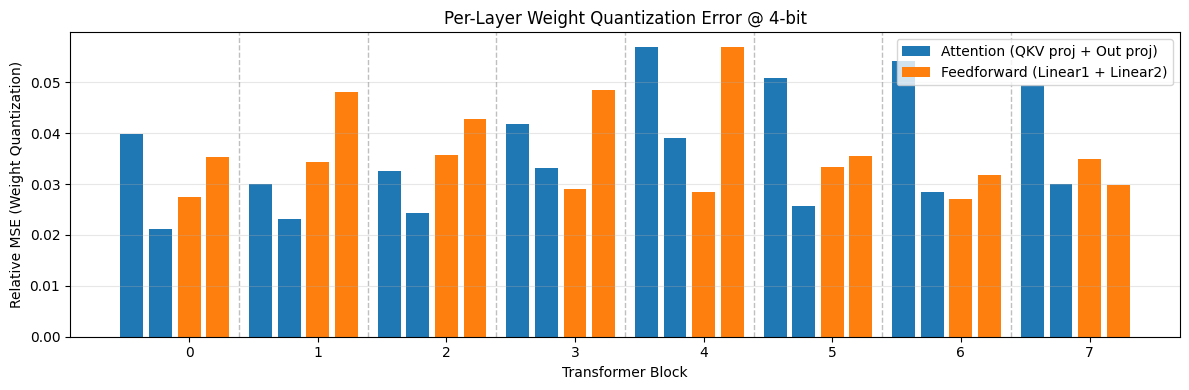

In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from matplotlib.patches import Patch

def plot_weight_quantization_error(model: ShakespeareModule, bitwidth=8):
    errors = []
    block_ids = []
    layer_names = []
    
    for name, mod in model.model.transformer_blocks.named_modules():
        if isinstance(mod, nn.Linear):
            # Quantize weights
            q_w, w_s = QLinear._quantize_tensor(mod.weight.data, bitwidth)
            # Compute relative MSE
            mse = torch.mean((mod.weight.data - q_w * w_s) ** 2)
            norm = torch.mean(mod.weight.data ** 2)
            rel_error = mse / norm
            
            # Parse block id and layer type
            if '.' in name:
                block_id, layer_type = name.split('.', 1)
                block_ids.append(int(block_id))
                layer_names.append(layer_type)
                errors.append(rel_error.item())
    
    # Group by blocks
    unique_blocks = sorted(list(set(block_ids)))
    
    # Create positions with spacing between blocks
    positions = []
    colors = []
    x_pos = 0
    block_boundaries = []
    
    for block in unique_blocks:
        block_start = x_pos
        for i, (bid, layer) in enumerate(zip(block_ids, layer_names)):
            if bid == block:
                positions.append(x_pos)
                # Color based on layer type
                if 'attn' in layer.lower():
                    colors.append('tab:blue')
                else:
                    colors.append('tab:orange')
                x_pos += 1
        
        # Add spacing between blocks
        x_pos += 0.5
        block_boundaries.append((block_start + x_pos - 0.5) / 2)  # Middle of block for tick
    
    # Plot
    plt.figure(figsize=(12, 4))
    bars = plt.bar(positions, errors, color=colors, width=0.8)
    
    # Add vertical lines between blocks
    for block in unique_blocks[:-1]:  # Don't add line after last block
        # Find the last bar position of current block
        last_pos = [p for p, b in zip(positions, block_ids) if b == block][-1]
        plt.axvline(x=last_pos + 0.75, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Set x-ticks at block centers
    plt.xticks(ticks=block_boundaries, labels=unique_blocks, rotation=0)
    plt.xlabel("Transformer Block")
    plt.ylabel("Relative MSE (Weight Quantization)")
    plt.title(f"Per-Layer Weight Quantization Error @ {bitwidth}-bit")
    plt.tight_layout()
    
    # Improved legend with more detail
    legend_elements = [
        Patch(facecolor='tab:blue', label='Attention (QKV proj + Out proj)'),
        Patch(facecolor='tab:orange', label='Feedforward (Linear1 + Linear2)'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Example usage
model = ShakespeareModule.load_from_checkpoint(
    'src/lab1/checkpoints/pretrained/float-best-large.ckpt',
    batch_size=6
)
plot_weight_quantization_error(model, bitwidth=4)

## 3. Accuracy Metric: Validation Loss on a Single Batch

In transitioning to \textbf{software-hardware co-design}, our objective is to explore the space of per-layer bitwidth configurations under a unified cost function balancing \textbf{memory footprint} and \textbf{task accuracy}.

To quantify the \textbf{accuracy degradation} introduced by quantization, we measure the \textbf{percentage change in validation loss} between the quantized model and its full-precision counterpart on a single held-out validation batch. This captures how quantization impacts the model’s predictive quality in a \textbf{task-relevant and normalized} manner, enabling rapid evaluation during the search process.

Given the cross-entropy losses for the quantized and full-precision models,
\begin{equation}
\mathcal{L}_{\text{val}}^{(q)} \quad \text{and} \quad \mathcal{L}_{\text{val}}^{(fp)},
\end{equation}
the \textbf{percentage change} is defined as:
\begin{equation}
\Delta_{\text{loss}} = \frac{\mathcal{L}_{\text{val}}^{(q)} - \mathcal{L}_{\text{val}}^{(fp)}}{\mathcal{L}_{\text{val}}^{(fp)}} \times 100\%.
\end{equation}

Each validation loss $\mathcal{L}_{\text{val}}$ is computed using the standard \textbf{cross-entropy} formulation:
\begin{equation}
\mathcal{L}_{\text{val}} = -\frac{1}{B} \sum_{i=1}^B \log \left( \frac{e^{z_{i, y_i}}}{\sum_{j=1}^V e^{z_{i, j}}} \right),
\end{equation}
where $B$ is the batch size, $V$ the vocabulary size, $\mathbf{z} \in \mathbb{R}^{B \times V}$ the model logits, and $y$ the ground-truth labels.

In PyTorch, this can be implemented as:

```python
loss_fp = F.cross_entropy(logits_fp, y)
loss_q = F.cross_entropy(logits_q, y)
delta_loss = 100 * (loss_q.item() - loss_fp.item()) / loss_fp.item()
```

\noindent\textbf{Note:} Measuring the \textit{relative} change rather than the raw loss value allows comparison across tasks and configurations where the baseline loss may vary.
This metric captures the \textbf{end-to-end effect of quantization} on model outputs in a normalized form, making it a robust proxy for task-specific performance degradation in a \textbf{hardware-aware optimization loop}.



In [6]:
def compute_validation_loss(model, loss_fn, dataloader, device):
    model.eval()
    
    with torch.no_grad():
        x, y = next(iter(dataloader))
        x, y = x.to(device), y.to(device)
        logits = model.model(x)
        logits = logits.view(-1, logits.size(-1)) 
        y = y.view(-1) 
        loss = loss_fn(logits, y)
        
    return loss.item()


## 4. Memory Metric: Percentage Change in Static Model Size

In our **software-hardware co-design** cost function, we must also quantify the **hardware cost** associated with any quantization configuration.  
Rather than reporting absolute memory size, we measure the **percentage change in static memory consumption** between the quantized model and its full-precision baseline.  
This provides a normalized metric for how quantization affects the model’s memory footprint, allowing comparison across architectures and quantization schemes.

Given the static memory footprints (in bytes) of the quantized and full-precision models,

$$
M^{(q)} \quad \text{and} \quad M^{(fp)},
$$

the percentage change in memory consumption is defined as:

$$
\Delta_{\text{mem}} = \frac{M^{(q)} - M^{(fp)}}{M^{(fp)}} \times 100\%.
$$

Each static memory footprint \(M\) is computed as the total size of all model parameters, accounting for quantized and unquantized components according to the configuration `qconfig`.

### What Gets Counted?

- **Quantized weights** (e.g., `QLinear.qweight`) are stored using the **bit-width** defined in `qconfig`.
- **Biases, embeddings, and normalization layers** are retained in **full precision** (32 bits per parameter).
- **Other unquantized parameters** (e.g., LayerNorm scales or modules not explicitly quantized) are also assumed to be **32-bit floats**.

For a quantized linear layer with weight shape \([m, n]\) and bit-width \(b\), the contribution to memory is:

$$
\text{Size}_{\text{qweight}} = m \times n \times b \text{ bits}.
$$

Full-precision components (e.g., biases) contribute:

$$
\text{Size}_{\text{fp32}} = k \times 32 \text{ bits}.
$$

The total model size \(M\) is obtained by summing all layer contributions and converting from bits to bytes:

$$
M = \frac{1}{8} \left( \sum_{\ell} \text{Size}_{\text{qweight}, \ell} + \sum_{\ell} \text{Size}_{\text{fp32}, \ell} \right).
$$

In PyTorch, the comparison can be implemented as:

```python
size_fp = compute_model_size_bytes(model_fp)
size_q = compute_model_size_bytes(model_q)
delta_mem = 100 * (size_q - size_fp) / size_fp
```

> **Note:**  
> Measuring the *relative* change in memory rather than the raw size directly integrates with the joint cost function, ensuring the optimization process considers both **accuracy** and **hardware efficiency** on a comparable scale.



In [7]:
def compute_model_size_bytes(root: nn.Module, qconfig: Dict[str, int]):
    total_bits = 0
    for path, bw in qconfig.items():
        parent_path, _, attr = path.rpartition('.')
        parent = root if not parent_path else root.get_submodule(parent_path)
        lin: QLinear = getattr(parent, attr)
        total_bits += lin.qweight.numel() * bw
        if lin.bias is not None:
            total_bits += lin.bias.numel() * 32
    for name, param in root.named_parameters():
        if name.endswith('bias') or 'weight' not in name:
            continue
        param_module = name.rsplit('.', 1)[0]
        if any(path.startswith(param_module) for path in qconfig):
            continue
        total_bits += param.numel() * 32
    return total_bits // 8

## 5. HyperOpt Objective: Balancing Accuracy and Efficiency

With well-defined **relative** metrics for accuracy and memory, we construct a **scalarized objective** that trades off predictive performance against model compactness.

We now combine the **percentage change** in validation loss and the **percentage change** in static model size:

$$
\mathcal{L}_{\text{total}}
= \alpha \cdot \Delta_{\text{loss}}^{(\%)} + (1 - \alpha)\cdot \Delta_{\text{mem}}^{(\%)}
$$

where the two terms are defined (on the **same fixed validation batch**) as

$$
\Delta_{\text{loss}}^{(\%)} = \frac{\mathcal{L}_{\text{val}}^{(q)} - \mathcal{L}_{\text{val}}^{(fp)}}{\mathcal{L}_{\text{val}}^{(fp)}} \times 100\%, 
\qquad
\Delta_{\text{mem}}^{(\%)} = \frac{M^{(q)} - M^{(fp)}}{M^{(fp)}} \times 100\%.
$$

- $\mathcal{L}_{\text{val}}^{(q)}$ and $\mathcal{L}_{\text{val}}^{(fp)}$ are cross-entropy losses of the **quantized** and **full-precision** models on the **same held-out batch**.  
- $M^{(q)}$ and $M^{(fp)}$ are the corresponding **static parameter sizes** (bytes/MB) after quantization vs. the FP baseline.  
- $\alpha \in [0,1]$ tunes the trade-off: higher $\alpha$ emphasizes accuracy retention; lower $\alpha$ emphasizes compression.

We **minimize** $\mathcal{L}_{\text{total}}$ in HyperOpt (or any HPO engine). Negative values indicate improvements vs. baseline (e.g., reduced loss or reduced size), positive values indicate regressions.

> **Practical notes**
> - Use a **fixed** validation batch for both models to avoid injecting variance into $\Delta_{\text{loss}}^{(\%)}$.
> - If you want to penalize only regressions, clamp negatives:  
>   $\Delta_{\text{loss}}^{(\%)} \leftarrow \max(0,\Delta_{\text{loss}}^{(\%)})$,  
>   $\Delta_{\text{mem}}^{(\%)} \leftarrow \max(0,\Delta_{\text{mem}}^{(\%)})$.
> - Because both terms are in **percent**, no ad-hoc rescaling is needed; $\alpha$ alone controls the trade-off.

> **Trade-off knob**  
> - $\alpha=0.2$: stronger push for compactness (tolerates accuracy loss).  
> - $\alpha=0.8$: stronger push for accuracy retention (tolerates larger size).  
> - $\alpha=0.5$: balanced emphasis; improvements in either dimension reduce the objective.


In [8]:
def objective(qconfig, alpha, fp_val_loss, fp_size_mb):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q = ShakespeareModule.load_from_checkpoint(
        'src/lab1/checkpoints/pretrained/float-best-large.ckpt', batch_size=16)
    q.setup('test')
    quantize_model(q, qconfig).to(device)

    dl = q.test_dataloader()
    q_val_loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)
    delta_loss = (q_val_loss - fp_val_loss) / fp_val_loss

    q_size_mb = compute_model_size_bytes(q, qconfig) / (1024 ** 2)
    delta_mb = (q_size_mb - fp_size_mb) / fp_size_mb
    #print("delta loss", delta_loss, "delta mb", delta_mb)
    loss = alpha * delta_loss + (1 - alpha) * delta_mb
    return {'loss': loss, 'status': STATUS_OK}


## 6. Search Space & Optimization Driver

Having defined a scalar objective function above that balances accuracy and memory efficiency, the next step is to explore the **combinatorial space of per-layer bit-width assignments** in search of an optimal quantization configuration.

This process requires two components which are defined inside the `hyperopt_search` function below:

- A **search space**: defines which bit-widths can be assigned to each quantizable layer
- A **search driver**: proposes candidate configurations and evaluates them using the scalarized objective

### Search Space

We restrict quantization to a discrete set of bit-widths, typically `[3, 4, 5, 6, 7, 8]`.  
Each `nn.Linear` layer in the model gets its own bit-width choice, so for a model with $L$ quantizable layers, the total search space contains $6^L$ configurations, making exhaustive enumeration intractable for non-trivial models.

To define the space using `hyperopt`:

```python
space = {
    name: hp.choice(name, [3, 4, 5, 6, 7, 8])
    for name in linear_layer_names(model)
}

```

### Search Driver

We use `hyperopt.fmin()` to minimize the total loss:

$
\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{val}} + (1 - \alpha) \cdot \text{Size}_{\text{MB}}
$

The driver works iteratively:
1. Propose a candidate `qconfig` from the search space  
2. Apply quantization according to that configuration  
3. Evaluate:
   - **Accuracy** via cross-entropy loss on a validation batch  
   - **Size** via the static memory estimate of the quantized model  

Over many iterations, the optimization converges toward configurations that optimally trade off model size and accuracy, according to the weight $\alpha$.

By default, we use the **Tree-structured Parzen Estimator** (`tpe.suggest`) for guided exploration, but other strategies (e.g., bayesian) can be substituted depending on performance and exploration needs.

>  **Tip for faster search**:  
> Simplify the bit-width set (e.g., restrict to `[4, 6, 8]`) to reduce the search space or reduce the number of trials.



In [11]:
def hyperopt_search(init_cfg, max_evals=100, alpha=0.10):
    space = {k: hp.choice(k, [2, 3, 4, 5, 6, 7, 8]) for k in init_cfg}
    trials = Trials()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # compute the highest precision model size (8-bit)
    baseline_model = ShakespeareModule.load_from_checkpoint('src/lab1/checkpoints/pretrained/float-best-large.ckpt', batch_size=16)
    
    start_cfg = default_qconfig(baseline_model, bitwidth=32)
    quantize_model(baseline_model, start_cfg)
    fp_size_mb = compute_model_size_bytes(baseline_model, start_cfg) / (1024 **2)

    # compute the val loss with that model 
    baseline_model.setup('test')
    baseline_model = baseline_model.to(device)
    dl = baseline_model.test_dataloader()
    fp_val_loss = compute_validation_loss(baseline_model, nn.CrossEntropyLoss(), dl, device)

    # provide the baseline measurements fp_val_loss, fp_size_mb and your cost preference alpha, to define the objective
    fn = partial(objective, alpha=alpha, fp_val_loss=fp_val_loss, fp_size_mb=fp_size_mb)
    best = fmin(fn, space, algo=tpe.suggest, max_evals=max_evals, trials=trials)
    return space_eval(space, best)

##  7. Main Entry Point: Running the Full Quantization Search

This function below `optimize_qconfig` orchestrates the **end-to-end quantization search pipeline**, tying together model loading, configuration setup, and the optimization loop.

It performs the following steps:

1. **Load a pretrained model** from a checkpoint (assumed to be full-precision).
2. **Generate an initial quantization config**, assigning 8-bit precision to all linear layers.
3. **Invoke `hyperopt_search()`** to explore alternative per-layer bit-widths under the scalarized objective.
4. **Return the best-performing configuration**, balancing task accuracy and memory efficiency.

The returned `best_qconfig` can then be used to quantize the model for deployment, fine-tuning, or further analysis.


In [12]:
def optimize_qconfig():
    base = ShakespeareModule.load_from_checkpoint('src/lab1/checkpoints/pretrained/float-best-large.ckpt')
    start_cfg = default_qconfig(base, bitwidth=8)
    best_cfg = hyperopt_search(start_cfg)
    return best_cfg

best_qconfig = optimize_qconfig()

100%|██████| 100/100 [03:15<00:00,  1.96s/trial, best loss: -0.5819505515117043]


In [13]:
best_qconfig

{'model.transformer_blocks.0.feed_forward.linear1': 8,
 'model.transformer_blocks.0.feed_forward.linear2': 3,
 'model.transformer_blocks.0.self_attn.out_proj': 4,
 'model.transformer_blocks.0.self_attn.qkv_proj': 6,
 'model.transformer_blocks.1.feed_forward.linear1': 4,
 'model.transformer_blocks.1.feed_forward.linear2': 6,
 'model.transformer_blocks.1.self_attn.out_proj': 5,
 'model.transformer_blocks.1.self_attn.qkv_proj': 8,
 'model.transformer_blocks.2.feed_forward.linear1': 8,
 'model.transformer_blocks.2.feed_forward.linear2': 8,
 'model.transformer_blocks.2.self_attn.out_proj': 5,
 'model.transformer_blocks.2.self_attn.qkv_proj': 4,
 'model.transformer_blocks.3.feed_forward.linear1': 6,
 'model.transformer_blocks.3.feed_forward.linear2': 5,
 'model.transformer_blocks.3.self_attn.out_proj': 3,
 'model.transformer_blocks.3.self_attn.qkv_proj': 5,
 'model.transformer_blocks.4.feed_forward.linear1': 2,
 'model.transformer_blocks.4.feed_forward.linear2': 3,
 'model.transformer_blocks

##  8. Visualizing the Quantization Strategy

Once the quantization search completes, it’s insightful to examine **how bit-widths were assigned across the model architecture**. This helps identify which components the optimizer considered **sensitive** to quantization and which were more **robust to compression**.

### Per-block Bit-width Allocation

The visualization below summarizes the selected bit-widths by transformer block, categorized into:

- **Feed-forward layers**: `linear1`, `linear2`  
- **Self-attention layers**: `qkv_proj`, `out_proj`

For each transformer block, we display the bit-widths assigned to its constituent layers **side by side**, enabling pattern recognition — e.g., whether early layers retain higher precision, or certain layer types are consistently quantized more aggressively.

Let’s begin by visualizing the bit-width configuration produced by **your own quantization search**:


In [14]:
import re
import matplotlib.pyplot as plt
import numpy as np

def plot_bitwidth_config_per_layer(bitwidths: dict, title: str = 'Per-Layer Bit-Width Configuration', figsize: tuple = (12, 6)):
    """
    Plot per-layer bar charts of bit-widths for all components
    within each transformer block.
    
    Parameters
    ----------
    bitwidths : dict
        Mapping from layer names to bit-widths, e.g.
        'model.transformer_blocks.0.feed_forward.linear1': 4
    title : str
        Plot title.
    """
    # Organize bitwidths by block index and sub-layer
    layers = {}
    pattern = r'model\.transformer_blocks\.(\d+)\.(feed_forward|self_attn)\.([^\.]+)'
    
    for name, bw in bitwidths.items():
        m = re.match(pattern, name)
        if not m:
            continue
        idx, comp, sub = int(m.group(1)), m.group(2), m.group(3)
        block_name = f"Block {idx}"
        layers.setdefault(block_name, {})
        layer_label = f"{comp}.{sub}"
        layers[block_name][layer_label] = bw
    
    # Flatten to plot
    block_names = sorted(layers.keys(), key=lambda x: int(x.split()[-1]))
    all_labels = sorted({label for layer in layers.values() for label in layer.keys()})
    
    # Create positions with spacing between blocks
    bar_width = 0.8
    spacing_between_blocks = 0.5
    bars_per_block = len(all_labels)
    
    positions = []
    colors = []
    bitwidth_values = []
    block_centers = []
    
    x_pos = 0
    for block in block_names:
        block_start = x_pos
        for label in all_labels:
            positions.append(x_pos)
            bitwidth_values.append(layers[block].get(label, 0))
            
            # Assign colors: blue for attention, orange for feedforward
            if 'self_attn' in label:
                colors.append('tab:blue')
            else:
                colors.append('tab:orange')
            
            x_pos += 1
        
        # Calculate block center for tick placement
        block_centers.append((block_start + x_pos - 1) / 2)
        
        # Add spacing between blocks
        x_pos += spacing_between_blocks
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(positions, bitwidth_values, width=bar_width, color=colors)
    
    # Add vertical separator lines between blocks
    for i in range(len(block_names) - 1):
        separator_x = positions[bars_per_block * (i + 1) - 1] + bar_width/2 + spacing_between_blocks/2
        ax.axvline(x=separator_x, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Labels & styling
    ax.set_xlabel('Transformer Block')
    ax.set_ylabel('Bit-Width')
    ax.set_title(title)
    ax.set_xticks(block_centers)
    ax.set_xticklabels([b.split()[-1] for b in block_names], rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Create legend with layer type information
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tab:blue', label='Attention Layers'),
        Patch(facecolor='tab:orange', label='Feedforward Layers'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

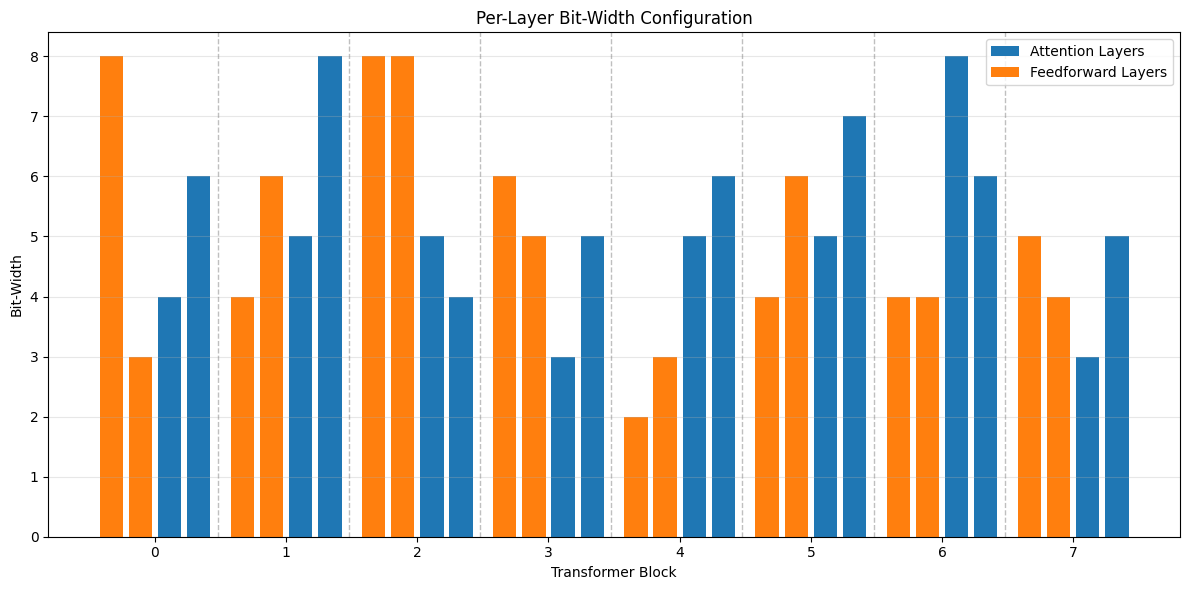

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Per-Layer Bit-Width Configuration'}, xlabel='Transformer Block', ylabel='Bit-Width'>)

In [15]:
plot_bitwidth_config_per_layer(best_qconfig)

### Comparing to a Precomputed Search Result

To get a sense of what longer or more thorough searches might yield, we can also visualize a **previously optimized configuration**, obtained via:

- **2000 trials**
- A strong accuracy preference: $\alpha = 0.2$

This provides a useful baseline or reference for understanding how the search process evolves with more iterations and different objective weights.

Let’s load and plot that configuration:


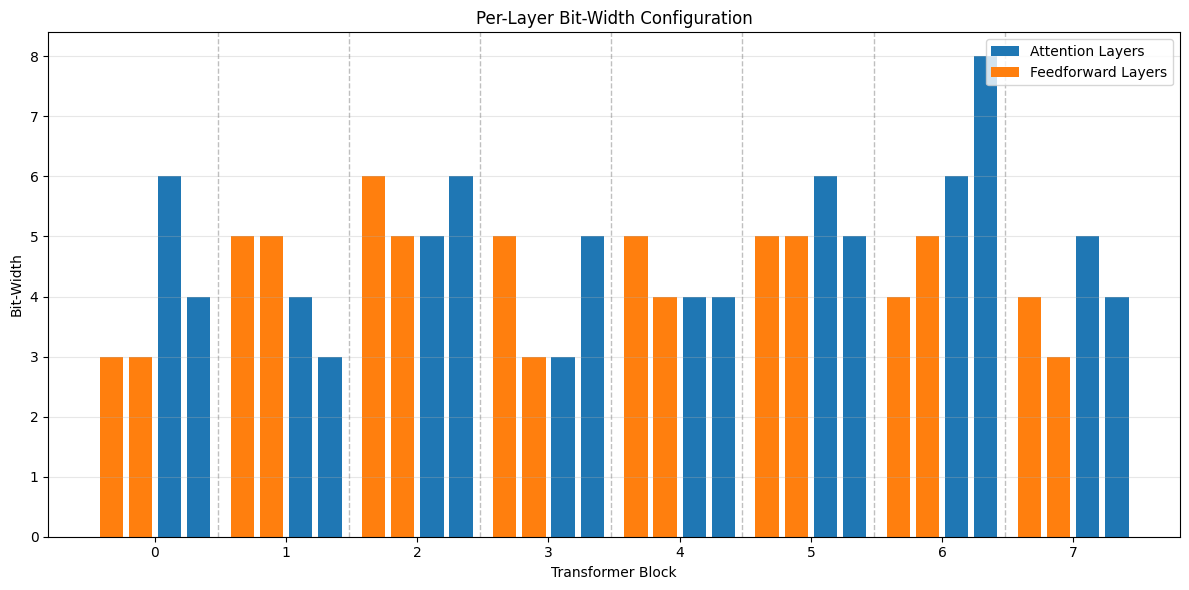

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Per-Layer Bit-Width Configuration'}, xlabel='Transformer Block', ylabel='Bit-Width'>)

In [16]:
import pickle

with open('src/lab1/checkpoints/pretrained/best_qconfig.pkl', 'rb') as f:
    best_qconfig = pickle.load(f)

plot_bitwidth_config_per_layer(best_qconfig)


##  9. Precision vs. Accuracy Trade-off

To assess the benefits of **mixed-precision quantization** in the context of software-hardware co-design, we compare it against simpler **uniform-precision baselines**, where all layers share the same bit-width.

### Experimental Setup

We evaluate the model under a range of uniform bit-widths (from 8-bit to 2-bit) and record:

- **Validation loss**: accuracy after quantization  
- **Model size**: static memory footprint (in MB)

We then compare these baselines to the **mixed-precision configuration** found by the search algorithm.

This analysis addresses a key question:  
**Can adaptive bit-width allocation yield better accuracy at a comparable or lower memory cost?**

### Plotting the Trade-off

The plot below illustrates the trade-off between model size and validation loss:

- The **blue curve** traces uniform-precision results (each point labeled with its bit-width)  
- The **grey diamond** highlights the mixed-precision result

If the grey diamond appears **below and to the left** of the curve, it demonstrates that the mixed strategy achieves a **superior accuracy–efficiency balance** compared to any fixed-precision alternative.


In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing.util
multiprocessing.util._exit_function = lambda: None

def plot_precision_results(precisions=(8, 7, 6, 5, 4, 3),
                           mixed_qconfig=None,
                           batch_size=6,
                           checkpoint_path='src/lab1/checkpoints/pretrained/float-best-large.ckpt'):
    """
    Runs validation for mixed-precision settings, plots single-precision
    curve plus (optional) mixed-precision point, and returns fig, ax.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    results, sizes = [], []

    # Evaluate each uniform precision
    for prec in precisions:
        q = ShakespeareModule.load_from_checkpoint(checkpoint_path, batch_size=batch_size)
        q.setup('test')
        cfg = default_qconfig(q, bitwidth=prec)
        quantize_model(q, cfg).to(device)
        dl = q.test_dataloader()
        loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)
        results.append(loss)
        sizes.append(compute_model_size_bytes(q, cfg) / (1024 ** 2))
        
    # evaluate mixed-precision quant configuration
    q = ShakespeareModule.load_from_checkpoint(checkpoint_path, batch_size=batch_size)
    q.setup('test')
    quantize_model(q, mixed_qconfig).to(device)
    dl = q.test_dataloader()
    loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)
    mem  = compute_model_size_bytes(q, mixed_qconfig) / (1024 ** 2)
    mixed_point = (mem, loss)

    # --- Start plotting ---
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Single-precision curve in default color C0
    ax.plot(sizes, results,
            marker='o',
            linestyle='-',
            linewidth=2,
            color='C0',
            label='Uniform Precision')

    # Annotate each point with its bitwidth
    for x, y, p in zip(sizes, results, precisions):
        ax.annotate(f"{p}-bit",
                    xy=(x, y),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center',
                    fontsize=10)

    # Mixed precision point in contrasting color C3
    if mixed_point:
        ax.scatter(*mixed_point,
                   s=120,
                   marker='D',
                   color='C3',
                   label='Mixed Precision',
                   zorder=5)
        ax.annotate("Mixed",
                    xy=mixed_point,
                    xytext=(10, -15),
                    textcoords="offset points",
                    fontsize=10,
                    arrowprops=dict(arrowstyle='->', lw=1, color='C3'))

    # A light dashed grid (major ticks only)
    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.6)

    # Axis labels, title, and ticks
    ax.set_xlabel('Model Size (MB)', fontsize=12)
    ax.set_ylabel('Validation Loss', fontsize=12)
    ax.set_title('Validation Loss vs. Quantization Precision', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=11)

    # Tight legend in corner
    ax.legend(loc='upper right', frameon=False, fontsize=11)

    fig.tight_layout()
    return fig, ax


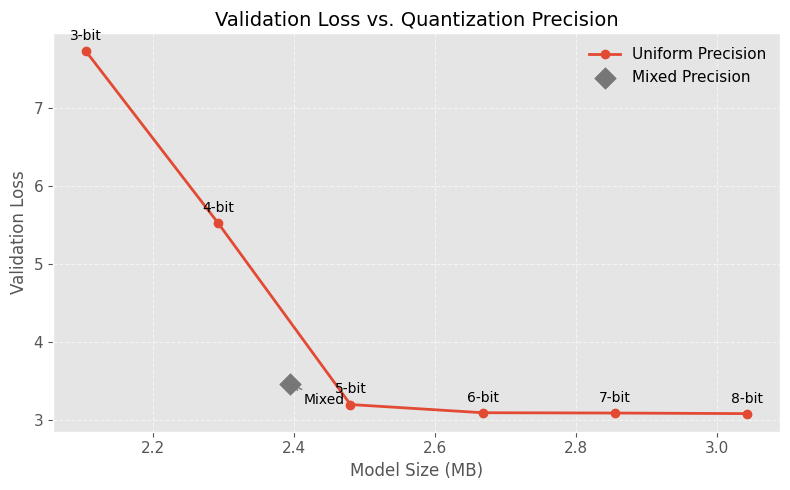

In [18]:
fig, ax = plot_precision_results(mixed_qconfig=best_qconfig)

You should see in the graph below, that the Mixed-Precision quantization solution falls, below the uniform precision line plot. It hence, provides an improved memory-accuracy trade-of thanks to the help of software-hardware co-design. 

## Conclusion

In this lab, we explored **post-training quantization** as a hardware–software co-design tool for optimizing transformer models. By implementing an integer-only `QLinear` layer and automating per-layer bit-width assignment using `hyperopt`, we demonstrated how quantization directly impacts both **model size** and **predictive performance**.

Our experiments showed that selectively reducing bit-widths (e.g., to 2–4 bits) yields significant memory savings with modest accuracy trade-offs. The scalarized loss function allowed us to balance these trade-offs, adapting the quantization strategy to hardware constraints.

This lab highlights a key principle in efficient ML deployment: *quantization is not a post-hoc hack, but a tunable design dimension*. Co-designing quantization levels per layer, based on actual hardware cost and accuracy impact, enables principled, deployable models for edge and embedded applications.